In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
movie=pd.read_csv('movie_preprocessed.csv')
movie.head()

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,19170001.0,103.0,Released,Enter the World of Pandora.,Avatar,7.2,235.0
1,1,15000000.0,"Adventure,Fantasy,Action",285.0,"ocean,drug abuse,exotic island,east india trad...",en,"Captain Barbossa, long believed to be dead, ha...",12.921594,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,19-05-2007,19170001.0,103.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,235.0
2,2,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,19170001.0,148.0,Released,A Plan No One Escapes,Spectre,6.3,235.0
3,3,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,19170001.0,103.0,Released,The Legend Ends,The Dark Knight Rises,7.6,235.0
4,4,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,19170001.0,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,235.0


In [4]:
movie.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
credit=pd.read_csv('credit_preprocessed.csv')
credit.head()


,Unnamed: 0,movie_id,title,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,19995,Avatar,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,285,Pirates of the Caribbean At Worlds End,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,Stephen E. Rivkin,Rick Heinrichs,John Dexter,Liz Dann,Hans Zimmer,Dariusz Wolski
2,2,206647,Spectre,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
3,3,49026,The Dark Knight Rises,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
4,4,49529,John Carter,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel


In [6]:
credit.drop(columns=['Unnamed: 0'], inplace=True)

In [7]:
df=movie.set_index('title').join(credit.set_index('title'),on='title',how='inner')
df.head(5)

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,...,vote_count,movie_id,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
title,,,,,,,,,,,,,,,,,,,,,
Avatar,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,...,235.0,19995,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
Spectre,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,...,235.0,206647,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
The Dark Knight Rises,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,...,235.0,49026,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
John Carter,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,...,235.0,49529,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel
Tangled,15000000.0,"Animation,Family",38757.0,"hostage,magic,horse,fairy tale,musical,princes...",en,When the kingdom's most wanted-and most charmi...,48.681969,"Walt Disney Pictures,Walt Disney Animation Stu...",United States of America,24-11-2010,...,235.0,38757,"Zachary Levi,Mandy Moore,Donna Murphy,Ron Perl...",Byron Howard,Tim Mertens,Douglas Rogers,David Goetz,Unknown,Alan Menken,Unknown


# What is the average runtime of movies produced

In [8]:
print('=====Average runtime=====')
print(movie['runtime'].mean())

=====Average runtime=====
105.32438059546116


# Is there a relationship between runtime and audience ratings

In [9]:
corr=movie['runtime'].corr(movie['vote_average'])
print('=====Correlation between runtime and vote average=====')
print(corr)

=====Correlation between runtime and vote average=====
0.3258066545575135


# Which specific runtime length gives the highest average audience rating

In [10]:
grp=movie.groupby(['runtime'])['vote_average'].mean()
print('=====Runtime wise average vote average=====')
print(grp.head(10))
print('\n=====Maximum average vote average=====')
print(grp.max())
best_runtime = grp.idxmax()
print(f'Runtime with highest average rating: {best_runtime} minutes')

=====Runtime wise average vote average=====
runtime
59.0    7.700000
60.0    6.200000
63.0    6.800000
64.0    6.000000
66.0    5.100000
67.0    6.200000
68.0    6.066667
69.0    6.433333
70.0    6.400000
72.0    6.440000
Name: vote_average, dtype: float64

=====Maximum average vote average=====
7.7
Runtime with highest average rating: 59.0 minutes


# How many movies fall within each runtime range

=== Runtime Range Distribution ===
               count
runtime_range       
0-60               1
60-90            662
90-120          3226
120-150          894
150+              20

Most common runtime range: 90-120 (3226 movies)


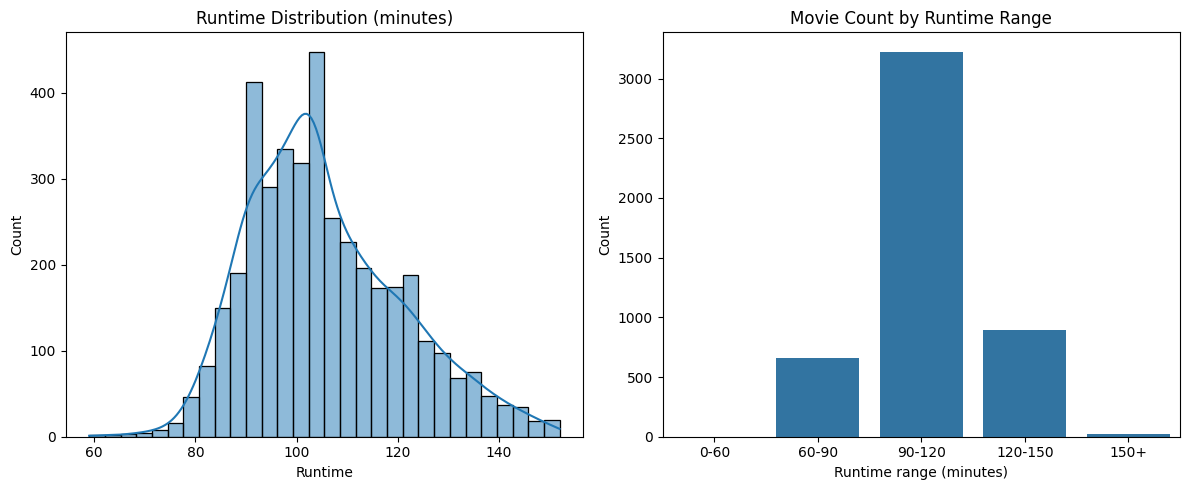

In [11]:
df1 = movie.copy()
bins = [0,60,90,120,150,1000]   
labels = ['0-60','60-90','90-120','120-150','150+']
df1['runtime_range'] = pd.cut(df1['runtime'], bins=bins, labels=labels, right=False)
range_counts = df1['runtime_range'].value_counts().reindex(labels).fillna(0).astype(int)
summary = pd.DataFrame({'count': range_counts})

print("=== Runtime Range Distribution ===")
print(summary)

most_common = summary['count'].idxmax()
most_common_count = summary['count'].max()
print(f"\nMost common runtime range: {most_common} ({most_common_count} movies)")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['runtime'], bins=30, kde=True)
plt.title('Runtime Distribution (minutes)')
plt.xlabel('Runtime')

plt.subplot(1,2,2)
sns.barplot(x=summary.index, y='count', data=summary.reset_index().rename(columns={'index':'range'}))
plt.title('Movie Count by Runtime Range')
plt.xlabel('Runtime range (minutes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Which genres have the longest or shortest average runtimes

=== Average Runtime (minutes) by Genre ===
              genre  avg_runtime_min
0           History           118.08
1               War           117.21
2             Drama           109.55
3         Adventure           109.20
4           Western           108.78
5            Action           108.64
6           Mystery           107.88
7             Crime           107.83
8           Romance           107.16
9             Music           107.01
10         Thriller           106.44
11          Foreign           106.24
12  Science Fiction           106.19
13          Fantasy           105.07
14           Comedy           100.09
15         TV Movie            98.62
16          Unknown            98.21
17           Horror            97.40
18           Family            96.98
19      Documentary            95.68
20        Animation            90.47


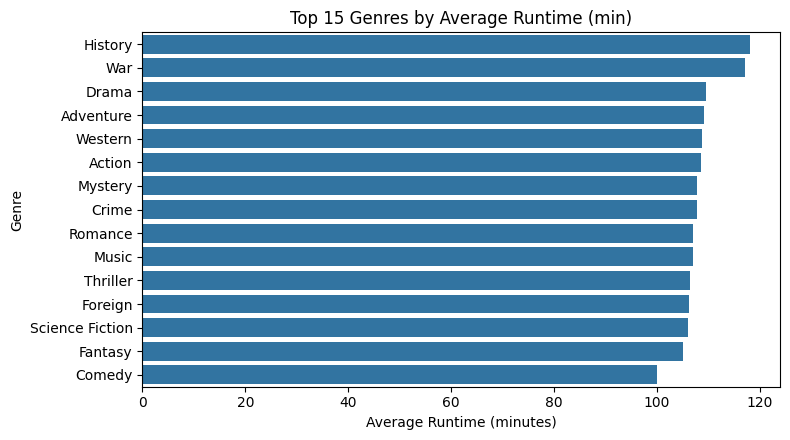

In [6]:
movie['genres_list'] = movie['genres'].apply(lambda x: [g.strip() for g in x.split(',') if g.strip() != ''])
movie_exploded = movie.explode('genres_list').copy()
movie_exploded = movie_exploded.rename(columns={'genres_list': 'genre'})

genre_runtime_avg = (movie_exploded.groupby('genre', sort=True)['runtime'].mean().round(2).sort_values(ascending=False).reset_index().rename(columns={'runtime': 'avg_runtime_min'}))
print("=== Average Runtime (minutes) by Genre ===")
print(genre_runtime_avg)

top_n = 15
plt.figure(figsize=(8, max(4, 0.3 * top_n)))
sns.barplot(x='avg_runtime_min', y='genre', data=genre_runtime_avg.head(top_n))
plt.title(f"Top {top_n} Genres by Average Runtime (min)")
plt.xlabel("Average Runtime (minutes)")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()



# Do longer movies get popularity even if ratings don’t improve

Pearson correlation between runtime and popularity: 0.208


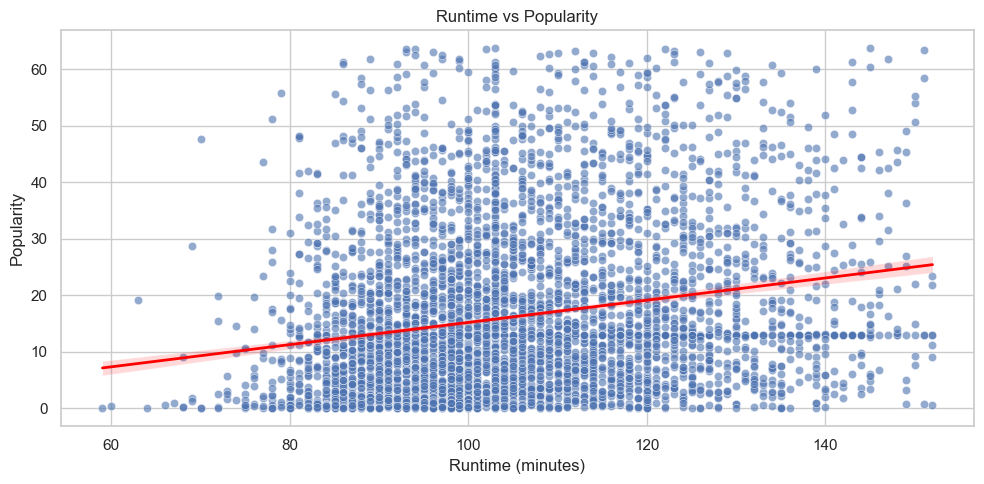

In [13]:
sns.set(style="whitegrid")
cols = ['runtime', 'popularity']
df = movie[cols].copy()
corr = df['runtime'].corr(df['popularity'])
print(f"Pearson correlation between runtime and popularity: {corr:.3f}")
plt.figure(figsize=(10,5))
sns.scatterplot(x='runtime', y='popularity', data=df, alpha=0.6)
sns.regplot(x='runtime', y='popularity', data=df, scatter=False, color='red', line_kws={'lw':2})
plt.title('Runtime vs Popularity')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()
